# **Задание №4. Проектирование базы данных для информационной системы**

## **Формулировка задания**

На основе ранее разработанных концептуальных основ проекта, иерархической структуры работ и UML-диаграмм, спроектируйте реляционную базу данных для вашей информационной системы. Результатом работы должна стать ER-диаграмма (Entity-Relationship Diagram), отражающая структуру данных, необходимых для функционирования вашего проекта.

## **Теоретическая часть: Основы проектирования реляционных баз данных**

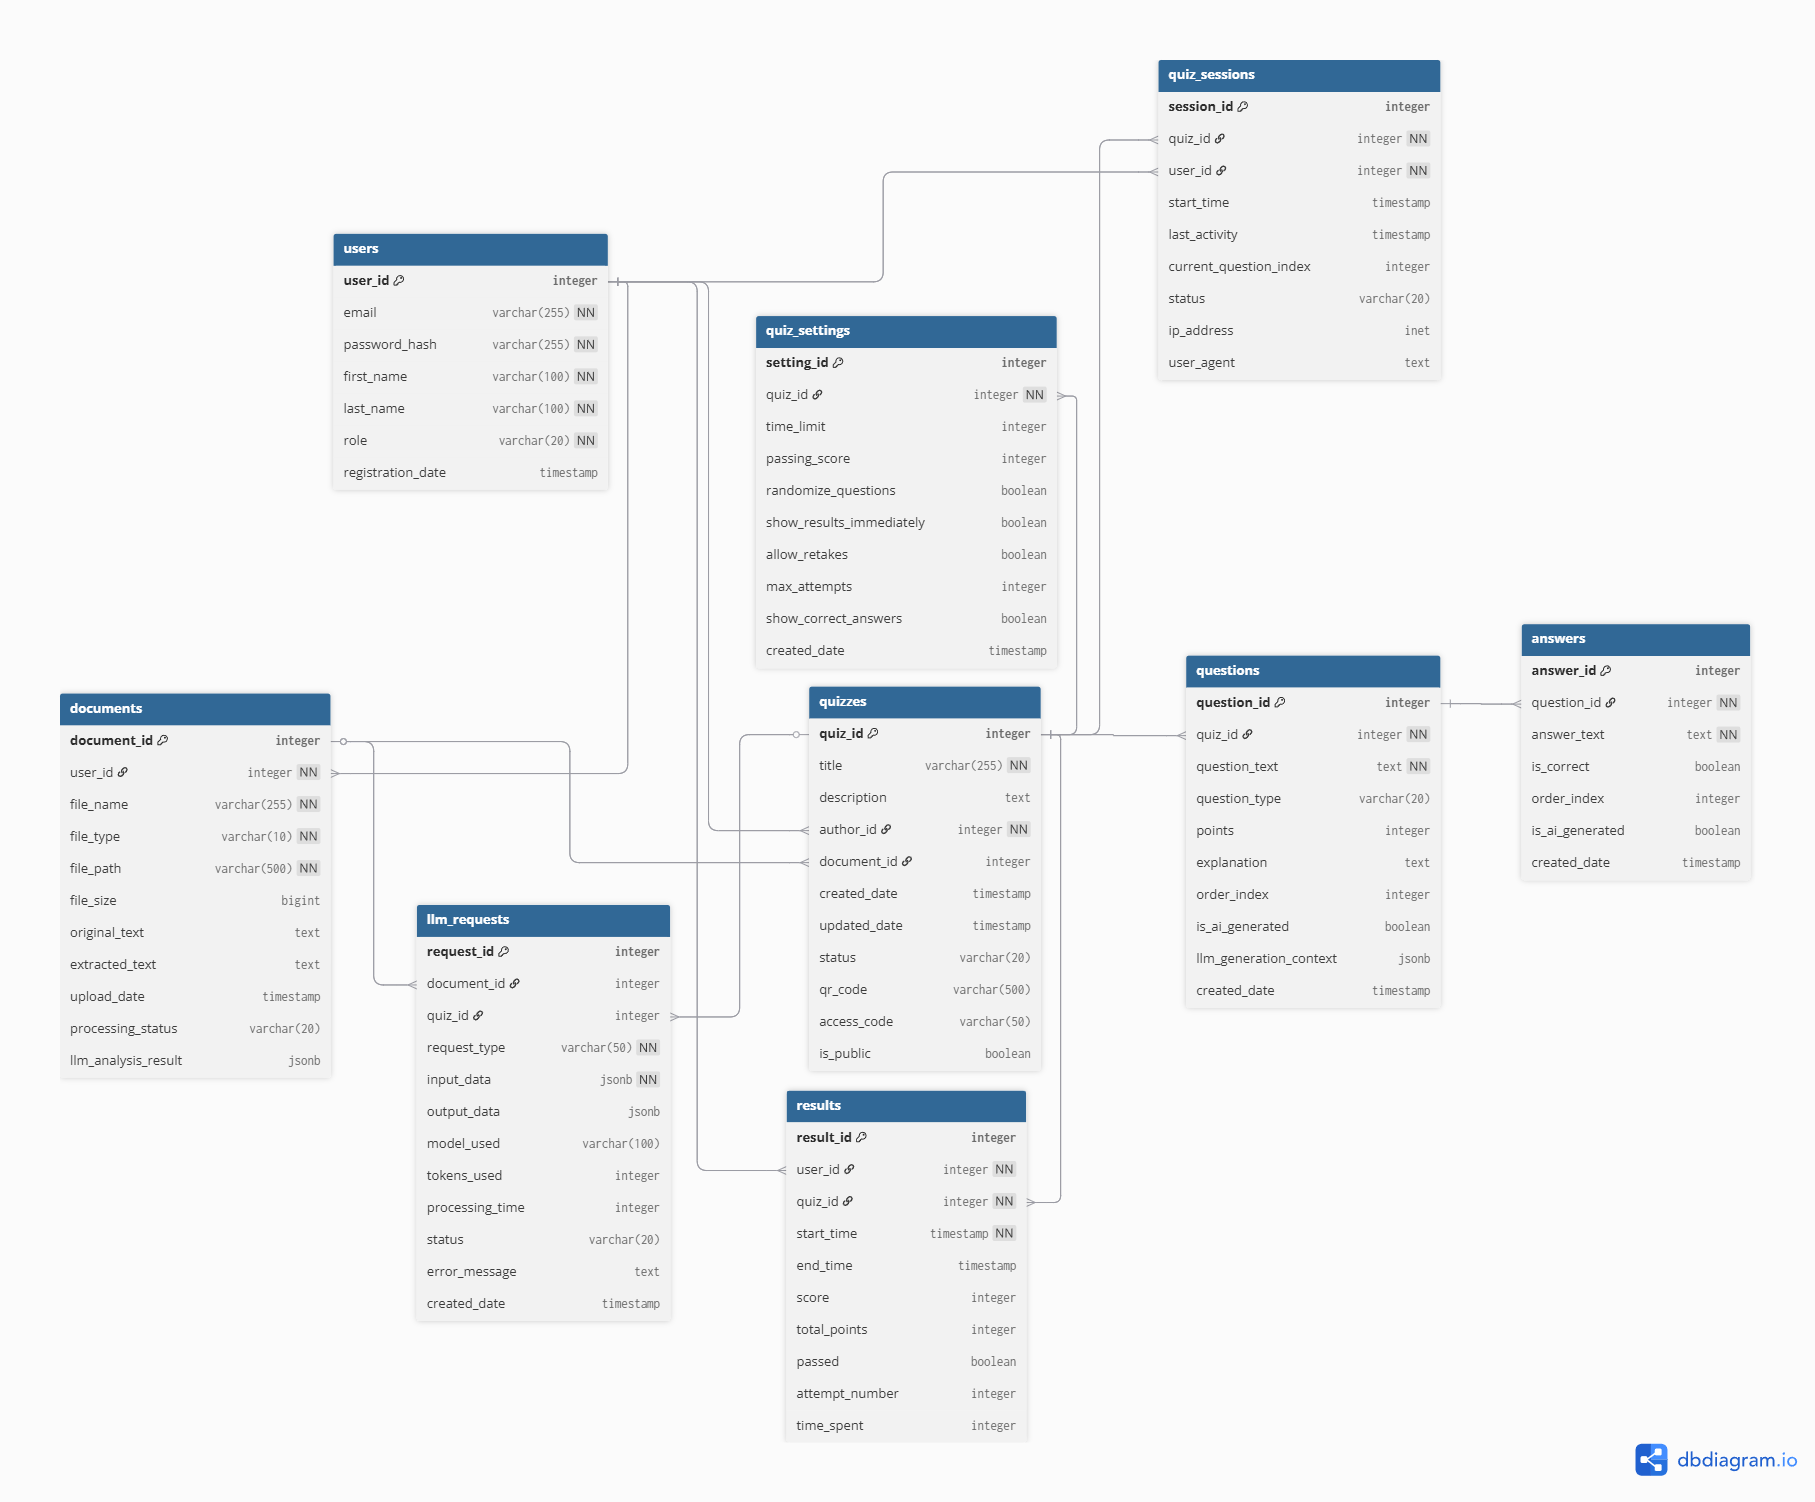

## **1. users (Пользователи)**
- `user_id` - уникальный идентификатор пользователя (автоинкремент)
- `email` - электронная почта для входа и уведомлений
- `password_hash` - хеш пароля для безопасности
- `first_name`, `last_name` - персональные данные пользователя
- `role` - роль в системе: teacher, student
- `registration_date` - дата и время регистрации

## **2. documents (Документы)**
**Назначение:** Хранение загруженных документов для анализа
- `document_id` - уникальный идентификатор документа
- `user_id` - владелец документа
- `file_name` - оригинальное имя файла
- `file_type` - расширение файла (pdf, docx, txt)
- `file_path` - путь к файлу в системе хранения
- `file_size` - размер файла в байтах
- `original_text` - исходный текст (если файл текстовый)
- `extracted_text` - текст, извлеченный из документа
- `upload_date` - время загрузки
- `processing_status` - статус обработки: pending, processing, completed, failed
- `llm_analysis_result` - результаты анализа LLM в формате JSON

## **3. quizzes (Квизы/Тесты)**
**Назначение:** Основная информация о тестах
- `quiz_id` - уникальный идентификатор теста
- `title` - название теста
- `description` - описание теста
- `author_id` - создатель теста
- `document_id` - исходный документ для генерации
- `created_date`, `updated_date` - даты создания и обновления
- `status` - статус: draft, published, archived
- `qr_code` - QR-код для быстрого доступа
- `access_code` - код доступа к тесту
- `is_public` - флаг публичного доступа

## **4. quiz_settings (Настройки теста)**
**Назначение:** Конфигурационные параметры тестирования
- `setting_id` - уникальный идентификатор настроек
- `quiz_id` - связанный тест
- `time_limit` - ограничение времени в минутах (0 = без ограничений)
- `passing_score` - проходной балл в процентах
- `randomize_questions` - перемешивание вопросов
- `show_results_immediately` - показ результатов сразу после завершения
- `allow_retakes` - разрешение пересдач
- `max_attempts` - максимальное количество попыток
- `show_correct_answers` - показ правильных ответов
- `created_date` - дата создания настроек

## **5. questions (Вопросы)**
**Назначение:** Вопросы, входящие в тест
- `question_id` - уникальный идентификатор вопроса
- `quiz_id` - принадлежность к тесту
- `question_text` - текст вопроса
- `question_type` - тип: single_choice, multiple_choice, true_false
- `points` - количество баллов за правильный ответ
- `explanation` - пояснение к вопросу
- `order_index` - порядковый номер в тесте
- `is_ai_generated` - флаг автоматической генерации
- `llm_generation_context` - контекст генерации LLM
- `created_date` - дата создания

## **6. answers (Ответы)**
**Назначение:** Варианты ответов на вопросы
- `answer_id` - уникальный идентификатор ответа
- `question_id` - принадлежность к вопросу
- `answer_text` - текст ответа
- `is_correct` - флаг правильности ответа
- `order_index` - порядковый номер
- `is_ai_generated` - флаг автоматической генерации
- `created_date` - дата создания

## **7. results (Результаты)**
**Назначение:** Результаты прохождения тестов
- `result_id` - уникальный идентификатор результата
- `user_id` - пользователь, прошедший тест
- `quiz_id` - пройденный тест
- `start_time`, `end_time` - время начала и окончания
- `score` - набранные баллы
- `total_points` - максимально возможные баллы
- `passed` - флаг успешного прохождения
- `attempt_number` - номер попытки
- `time_spent` - затраченное время в секундах

## **8. user_answers (Ответы пользователей)**
**Назначение:** Детализация ответов пользователя
- `user_answer_id` - уникальный идентификатор
- `result_id` - принадлежность к результату
- `question_id` - отвеченный вопрос
- `selected_answer_ids` - массив выбранных ответов
- `is_correct` - флаг правильности ответа
- `points_earned` - полученные баллы за вопрос
- `answered_at` - время ответа

## **9. quiz_sessions (Сессии тестирования)**
**Назначение:** Активные сессии прохождения тестов
- `session_id` - уникальный идентификатор сессии
- `quiz_id` - тест в сессии
- `user_id` - пользователь в сессии
- `start_time` - время начала сессии
- `last_activity` - время последней активности
- `current_question_index` - текущий вопрос
- `status` - статус: active, completed, abandoned
- `ip_address` - IP-адрес пользователя
- `user_agent` - информация о браузере

## **10. llm_requests (Запросы к LLM)**
**Назначение:** Аудит и логирование работы с нейросетями
- `request_id` - уникальный идентификатор запроса
- `document_id` - связанный документ
- `quiz_id` - связанный тест
- `request_type` - тип: document_analysis, question_generation, distractor_generation
- `input_data` - входные данные для LLM
- `output_data` - ответ от LLM
- `model_used` - используемая модель
- `tokens_used` - количество использованных токенов
- `processing_time` - время обработки в мс
- `status` - статус: pending, success, error
- `error_message` - сообщение об ошибке
- `created_date` - дата создания запроса

## **1. Базовые операции с пользователями**

### **Регистрация нового пользователя**
```sql
-- Создание основного пользователя
INSERT INTO users (email, password_hash, first_name, last_name, role)
VALUES ('ivanov@university.ru', 'hash123', 'Иван', 'Иванов', 'teacher')
RETURNING user_id;

-- Создание профиля преподавателя
INSERT INTO teachers (teacher_id, institution, subject, department)
VALUES (1, 'Технический Университет', 'Информатика', 'Кафедра ИС');
```

### **Аутентификация пользователя**
```sql
SELECT user_id, email, first_name, last_name, role, is_active
FROM users
WHERE email = 'batyr@miigaik.ru'
  AND password_hash = 'hash123'
  AND is_active = true;
```

### **Получение профиля пользователя с ролью**
```sql
-- Для преподавателя
SELECT u.*, t.institution, t.subject, t.department
FROM users u
JOIN teachers t ON u.user_id = t.teacher_id
WHERE u.user_id = 1;

-- Для студента  
SELECT u.*, s.student_number, s.group_name, s.year_of_study
FROM users u
JOIN students s ON u.user_id = s.student_id
WHERE u.user_id = 2;
```

## **2. Работа с документами и LLM**

### **Загрузка нового документа**
```sql
INSERT INTO documents (user_id, file_name, file_type, file_path, file_size, processing_status)
VALUES (1, 'lecture_ai.pdf', 'pdf', '/uploads/lecture_ai_123.pdf', 2048576, 'pending')
RETURNING document_id;
```

### **Обновление статуса обработки документа**
```sql
UPDATE documents
SET processing_status = 'completed',
    extracted_text = 'Текст лекции об искусственном интеллекте...',
    llm_analysis_result = '{"key_concepts": ["нейросети", "машинное обучение"], "difficulty": "medium"}'
WHERE document_id = 1;
```

### **Логирование запроса к LLM**
```sql
INSERT INTO llm_requests (document_id, request_type, input_data, model_used, status)
VALUES (1, 'document_analysis',
        '{"text": "Текст лекции...", "max_concepts": 10}',
        'gpt-4', 'pending');
```

## **3. Создание и управление квизами**

### **Создание нового квиза на основе документа**
```sql
INSERT INTO quizzes (title, description, author_id, document_id, status)
VALUES ('Тест по ИИ', 'Проверка знаний по искусственному интеллекту', 1, 1, 'draft')
RETURNING quiz_id;
```

### **Добавление настроек квиза**
```sql
INSERT INTO quiz_settings (quiz_id, time_limit, passing_score, randomize_questions, max_attempts)
VALUES (1, 30, 70, true, 3);
```

### **Создание вопросов, сгенерированных LLM**
```sql
-- Основной вопрос
INSERT INTO questions (quiz_id, question_text, question_type, points, is_ai_generated, llm_generation_context)
VALUES (1, 'Что такое нейронная сеть?', 'single_choice', 2, true,
        '{"source_concept": "нейросети", "confidence": 0.95}')
RETURNING question_id;

-- Варианты ответов
INSERT INTO answers (question_id, answer_text, is_correct, is_ai_generated) VALUES
(1, 'Математическая модель, имитирующая работу мозга', true, true),
(1, 'Программа для редактирования изображений', false, true),
(1, 'Тип компьютерной сети', false, true),
(1, 'Язык программирования', false, true);
```

## **4. Операции с тестированием**

### **Начало прохождения теста**
```sql
-- Создание сессии
INSERT INTO quiz_sessions (quiz_id, user_id, start_time, status, ip_address)
VALUES (1, 2, CURRENT_TIMESTAMP, 'active', '192.168.1.100')
RETURNING session_id;

-- Создание записи результата
INSERT INTO results (user_id, quiz_id, start_time, attempt_number)
VALUES (2, 1, CURRENT_TIMESTAMP, 1)
RETURNING result_id;
```

### **Сохранение ответа пользователя**
```sql
INSERT INTO user_answers (result_id, question_id, selected_answer_ids, answered_at)
VALUES (1, 1, ARRAY[1], CURRENT_TIMESTAMP); -- выбрал ответ с ID 1
```

### **Завершение теста и расчет результатов**
```sql
-- Обновление времени завершения
UPDATE results
SET end_time = CURRENT_TIMESTAMP,
    time_spent = EXTRACT(EPOCH FROM (CURRENT_TIMESTAMP - start_time))
WHERE result_id = 1;

-- Расчет баллов
UPDATE results
SET score = (
    SELECT COALESCE(SUM(points_earned), 0)
    FROM user_answers
    WHERE result_id = 1
),
total_points = (
    SELECT COALESCE(SUM(points), 0)
    FROM questions
    WHERE quiz_id = 1
),
passed = (
    SELECT (COALESCE(SUM(points_earned), 0) / NULLIF(SUM(points), 0) * 100) >= 70
    FROM user_answers ua
    JOIN questions q ON ua.question_id = q.question_id
    WHERE ua.result_id = 1
)
WHERE result_id = 1;

-- Закрытие сессии
UPDATE quiz_sessions
SET status = 'completed',
    last_activity = CURRENT_TIMESTAMP
WHERE session_id = 1;
```

## **5. Аналитика и отчетность**

### **Статистика по квизам преподавателя**
```sql
SELECT
    q.quiz_id,
    q.title,
    COUNT(DISTINCT r.result_id) as attempts_count,
    AVG(r.score) as avg_score,
    COUNT(DISTINCT CASE WHEN r.passed = true THEN r.user_id END) as passed_count,
    COUNT(DISTINCT r.user_id) as unique_users
FROM quizzes q
LEFT JOIN results r ON q.quiz_id = r.quiz_id
WHERE q.author_id = 1
GROUP BY q.quiz_id, q.title
ORDER BY q.created_date DESC;
```

### **Детальные результаты конкретного теста**
```sql
SELECT
    u.first_name,
    u.last_name,
    r.score,
    r.total_points,
    ROUND((r.score * 100.0 / NULLIF(r.total_points, 0)), 2) as percentage,
    r.passed,
    r.time_spent,
    r.attempt_number
FROM results r
JOIN users u ON r.user_id = u.user_id
WHERE r.quiz_id = 1
ORDER BY r.score DESC;
```

### **Анализ эффективности LLM-генерации**
```sql
SELECT
    request_type,
    COUNT(*) as total_requests,
    AVG(processing_time) as avg_processing_time,
    AVG(tokens_used) as avg_tokens,
    COUNT(CASE WHEN status = 'success' THEN 1 END) * 100.0 / COUNT(*) as success_rate
FROM llm_requests
WHERE created_date >= CURRENT_DATE - INTERVAL '30 days'
GROUP BY request_type;
```

### **Популярные тесты по количеству прохождений**
```sql
SELECT
    q.title,
    u.first_name || ' ' || u.last_name as author,
    COUNT(r.result_id) as total_attempts,
    q.created_date
FROM quizzes q
JOIN users u ON q.author_id = u.user_id
LEFT JOIN results r ON q.quiz_id = r.quiz_id
WHERE q.status = 'published'
GROUP BY q.quiz_id, q.title, u.first_name, u.last_name, q.created_date
ORDER BY total_attempts DESC
LIMIT 10;
```

## **6. Административные запросы**

### **Активные сессии тестирования**
```sql
SELECT
    q.title,
    u.first_name || ' ' || u.last_name as user_name,
    qs.start_time,
    qs.current_question_index,
    qs.last_activity
FROM quiz_sessions qs
JOIN quizzes q ON qs.quiz_id = q.quiz_id
JOIN users u ON qs.user_id = u.user_id
WHERE qs.status = 'active'
  AND qs.last_activity >= CURRENT_TIMESTAMP - INTERVAL '1 hour';
```

### **Поиск квизов по ключевым словам**
```sql
SELECT
    quiz_id,
    title,
    description,
    created_date
FROM quizzes
WHERE status = 'published'
  AND (title ILIKE '%искусственный интеллект%'
       OR description ILIKE '%искусственный интеллект%')
ORDER BY created_date DESC;
```